📥 **Stage 1 — Dataset Collection**

**Verify GPU Environment**

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

PyTorch version: 2.11.0+cpu
CUDA available: False
Running on CPU


In [ ]:
!pip install -q huggingface_hub

**Download Dataset from Hugging Face**

In [ ]:
from huggingface_hub import hf_hub_download

repo_id = "SujithVarma2005/credit-card-fraud-gans"

file_path = hf_hub_download(
    repo_id=repo_id,
    filename="creditcard.csv.zip",
    repo_type="dataset"
)

print("Downloaded to:", file_path)

Downloaded to: /root/.cache/huggingface/hub/datasets--SujithVarma2005--credit-card-fraud-gans/snapshots/7b298e04f044e5af7774805992d3f235007a2d7e/creditcard.csv.zip


**Extract the Dataset**

In [ ]:
import zipfile
import os

extract_dir = "/content/fraud_dataset"

with zipfile.ZipFile(file_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("Extracted files:")
print(os.listdir(extract_dir))

Extracted files:
['creditcard.csv']


**Load Dataset**

In [ ]:
import pandas as pd

csv_path = os.path.join(extract_dir, "creditcard.csv")

df = pd.read_csv(csv_path)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (284807, 31)

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


**Check Class Distribution**

In [ ]:
print("Class distribution:")
print(df["Class"].value_counts())

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64


**Calculate Class Percentages**

In [ ]:
class_percentage = df["Class"].value_counts(normalize=True) * 100

print("\nClass percentage:")
print(class_percentage)


Class percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


**Inspect Columns**

In [ ]:
print("Columns:")
print(df.columns.tolist())

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


**Inspect Data Types**

In [ ]:
print("\nData types:")
print(df.dtypes)


Data types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


**Checking Missing Values**

In [ ]:
print("\nMissing values:")
print(df.isnull().sum().sum())


Missing values:
0


📊 **Stage 2 — Exploratory Data Analysis (EDA)**

We start understanding the actual data before we clean or preprocess anything.

**Duplicate Transaction Analysis**

In [ ]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 1081


Dataset:

A

B

A  ← duplicate

B  ← duplicate

Extra duplicates = A, B → 2

**Analyze Duplicate Transactions**

In [ ]:
# Analyze the class distribution of duplicate rows

duplicate_rows = df[df.duplicated(keep=False)]

print("Total duplicate rows:", len(duplicate_rows))

print("\nClass distribution among duplicate rows:")
print(duplicate_rows["Class"].value_counts())

Total duplicate rows: 1854

Class distribution among duplicate rows:
Class
0    1822
1      32
Name: count, dtype: int64


A → original

B → original

A → duplicate

B → duplicate

So:

Rows involved in duplication = 4

original copy + duplicate copy

**Analyze Duplicate Rows by Class**

In [ ]:
# Count duplicate-group rows by class

duplicate_class_counts = duplicate_rows["Class"].value_counts()

print("Duplicate rows by class:")
print(duplicate_class_counts)

Duplicate rows by class:
Class
0    1822
1      32
Name: count, dtype: int64


In [ ]:
# Calculate percentage of duplicate-group rows by class

duplicate_class_percentage = duplicate_rows["Class"].value_counts(normalize=True) * 100

print("\nPercentage:")
print(duplicate_class_percentage)


Percentage:
Class
0    98.274002
1     1.725998
Name: proportion, dtype: float64


**Analyze Duplicate Frequency**

In [ ]:
# Count how many times each unique row appears

duplicate_frequency = df.value_counts()

# Show only rows that appear more than once
duplicate_frequency = duplicate_frequency[duplicate_frequency > 1]

print("Number of unique duplicated transactions:", len(duplicate_frequency))

print("\nFrequency of duplicated transactions:")
print(duplicate_frequency.value_counts().sort_index())

Number of unique duplicated transactions: 773

Frequency of duplicated transactions:
count
2     611
3      66
4      81
5      10
6       1
9       2
18      2
Name: count, dtype: int64


2 occurrences  → 611 transactions

3 occurrences  → 66

4 occurrences  → 81

5 occurrences  → 10

6 occurrences  → 1

9 occurrences  → 2

18 occurrences → 2

**Inspect Highly Repeated Transactions**


In [ ]:
# Find transactions that appear exactly 18 times

frequency_18 = df.value_counts()

transactions_18 = frequency_18[frequency_18 == 18]

print("Number of transactions appearing 18 times:", len(transactions_18))

print("\nTransactions appearing 18 times:")
print(transactions_18)

Number of transactions appearing 18 times: 2

Transactions appearing 18 times:
Time      V1         V2        V3        V4        V5        V6        V7        V8         V9        V10       V11       V12        V13        V14        V15       V16        V17        V18        V19       V20       V21        V22       V23        V24        V25        V26       V27        V28        Amount  Class
163152.0  -1.203617  1.574009  2.889277  3.381404  1.538663  3.698747  0.560211  -0.150911  0.124136  4.220998  1.384569  -0.706897  -0.256274  -1.562583  1.692915  -0.787338  -0.226776  -0.412354  0.234322  1.385597  -0.366727  0.522223  -0.357329  -0.870174  -0.134166  0.327019  -0.042648  -0.855262  1.51    0        18
          -1.196037  1.585949  2.883976  3.378471  1.511706  3.717077  0.585362  -0.156001  0.122648  4.217934  1.385525  -0.709405  -0.256168  -1.564352  1.693218  -0.785210  -0.228008  -0.412833  0.234834  1.375790  -0.370294  0.524395  -0.355170  -0.869790  -0.133198  0.32780

**Check the Class of the Highly Repeated Transactions**

In [ ]:
# Check whether the transactions repeated 18 times are
# legitimate or fraudulent

for transaction in transactions_18.index:
    mask = (df == transaction).all(axis=1)

    print("\nClass distribution:")
    print(df.loc[mask, "Class"].value_counts())


Class distribution:
Class
0    18
Name: count, dtype: int64

Class distribution:
Class
0    18
Name: count, dtype: int64


**Analyze Fraud Among Duplicate Transactions**

In [ ]:
# Analyze duplicate transactions by class

duplicate_class_counts = duplicate_rows["Class"].value_counts()

print("Duplicate rows by class:")
print(duplicate_class_counts)

print("\nFraudulent duplicate rows:", duplicate_class_counts.get(1, 0))
print("Legitimate duplicate rows:", duplicate_class_counts.get(0, 0))

Duplicate rows by class:
Class
0    1822
1      32
Name: count, dtype: int64

Fraudulent duplicate rows: 32
Legitimate duplicate rows: 1822


A **legitimate transaction** is a normal, genuine transaction made by the actual cardholder.

A **fraudulent transaction** is a transaction identified by the dataset as fraud.

Our dataset contains 284807

Legitimate - 284315

Fraudulent - 492

But in duplicate transactions we are having 1854

Legitimate - 1822

Fraudulent - 32

**Analyze Duplicate Class Percentage**

In [ ]:
# Calculate percentage of each class among duplicate rows

duplicate_class_percentage = (
    duplicate_rows["Class"].value_counts(normalize=True) * 100
)

print("Duplicate rows percentage by class:")
print(duplicate_class_percentage)

Duplicate rows percentage by class:
Class
0    98.274002
1     1.725998
Name: proportion, dtype: float64


**Check Duplicate Frequency by Class**

In [ ]:
# Analyze duplicate frequency separately for each class

duplicate_frequency_by_class = (
    duplicate_rows.groupby("Class")
    .size()
    .sort_index()
)

print("Duplicate rows by class:")
print(duplicate_frequency_by_class)

print("\nClass-wise duplicate percentage:")
print(
    duplicate_rows["Class"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

Duplicate rows by class:
Class
0    1822
1      32
dtype: int64

Class-wise duplicate percentage:
Class
0    98.274002
1     1.725998
Name: proportion, dtype: float64


**Analyze Transaction Amount**

In [ ]:
# Compare transaction amounts by class

print("Legitimate transactions:")
print(df[df["Class"] == 0]["Amount"].describe())

print("\nFraudulent transactions:")
print(df[df["Class"] == 1]["Amount"].describe())

Legitimate transactions:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

Fraudulent transactions:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


**Check Transaction Amount Distribution**

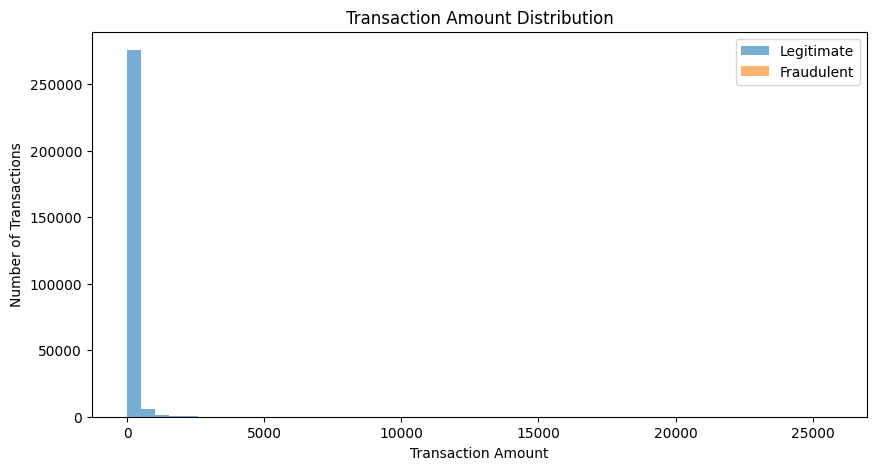

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    df[df["Class"] == 0]["Amount"],
    bins=50,
    alpha=0.6,
    label="Legitimate"
)

plt.hist(
    df[df["Class"] == 1]["Amount"],
    bins=50,
    alpha=0.6,
    label="Fraudulent"
)

plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.title("Transaction Amount Distribution")
plt.legend()
plt.show()

🧹 **Stage 3 — Data Cleaning**

Now we start cleaning the dataset.

**Recheck Missing Values**

In [ ]:
# Check for missing values in every column

missing_values = df.isnull().sum()

print("Missing values by column:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values by column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Total missing values: 0


**Check for Invalid Values**

In [ ]:
# Check for invalid values

print("Negative Time values:", (df["Time"] < 0).sum())
print("Negative Amount values:", (df["Amount"] < 0).sum())

print("\nUnique Class values:")
print(df["Class"].unique())

Negative Time values: 0
Negative Amount values: 0

Unique Class values:
[0 1]


**Handle Duplicate Rows**

We found:

1,854 rows belong to duplicated groups

773 unique duplicated transaction patterns

1,081 extra duplicate copies

We should not delete all 1,854 rows.

**Instead, our goal is: Keep one copy of each exact transaction and remove only the extra copies.**

In [ ]:
# Remove exact duplicate rows while keeping the first occurrence

df_clean = df.drop_duplicates()

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)

print("\nRows removed:", len(df) - len(df_clean))

Original dataset shape: (284807, 31)
Cleaned dataset shape: (283726, 31)

Rows removed: 1081


**Verify the Cleaned Dataset**

In [ ]:
# Verify the cleaned dataset

print("Cleaned dataset shape:", df_clean.shape)

print("\nRemaining duplicate rows:",
      df_clean.duplicated().sum())

print("\nClass distribution after cleaning:")
print(df_clean["Class"].value_counts())

Cleaned dataset shape: (283726, 31)

Remaining duplicate rows: 0

Class distribution after cleaning:
Class
0    283253
1       473
Name: count, dtype: int64


📊 **Our cleaned dataset**

Total: 283,726

🟢 Legitimate: 283,253

🔴 Fraudulent: 473

⚙️ **Stage - 4 Data Preprocessing**

Now our data is clean, so we can prepare it for machine learning.

**Our dataset has:**

Time

V1 → V28

Amount

Class

**Here:**

Time, V1–V28, Amount → features (X)

Class → target (y)

**Separate Features and Target**

In [ ]:
# Separate features and target

X = df_clean.drop("Class", axis=1)
y = df_clean["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

Features shape: (283726, 30)
Target shape: (283726,)

Feature columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']

Target distribution:
Class
0    283253
1       473
Name: count, dtype: int64


**Train/Test Split**

We'll use:

80% → Training

20% → Testing

stratify=y → keeps the fraud/legitimate proportion approximately the same in both sets.

In [ ]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())





Training set shape: (226980, 30)
Testing set shape: (56746, 30)

Training class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Testing class distribution:
Class
0    56651
1       95
Name: count, dtype: int64


**378 real fraudulent training transactions**

Those are what our **GAN will learn from**.

**Why use only the 378 fraud transactions?**

If we give the GAN both classes:

226,602 legitimate
        +
378 fraud
        ↓
       GAN

the data is extremely imbalanced:

~99.8% legitimate vs ~0.2% fraud.

**Feature Scaling**

**Why do we scale?**

Our features have very different numerical ranges.

scaled = x − μ / σ
	​


In [ ]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform test data
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (226980, 30)
Scaled testing shape: (56746, 30)


**Extract Fraudulent Training Transactions**

Now we need to give the GAN only the 378 fraudulent transactions from the training set.

We can use y_train to select them.

In [ ]:
# Extract only fraudulent transactions from the scaled training data

X_train_fraud = X_train_scaled[y_train.values == 1]

print("Fraudulent training data shape:", X_train_fraud.shape)

Fraudulent training data shape: (378, 30)


**Prepare Fraud Data for GAN Training**

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Convert fraud data to PyTorch tensor
fraud_tensor = torch.tensor(
    X_train_fraud,
    dtype=torch.float32
)

# Create dataset
fraud_dataset = TensorDataset(fraud_tensor)

# Create DataLoader
batch_size = 32

fraud_loader = DataLoader(
    fraud_dataset,
    batch_size=batch_size,
    shuffle=True
)

print("Fraud tensor shape:", fraud_tensor.shape)
print("Number of batches:", len(fraud_loader))

Fraud tensor shape: torch.Size([378, 30])
Number of batches: 12


**🎯 Stage 5 — Baseline Fraud Detection**

**Prepare Data for the Baseline Classifier**

For the baseline, we'll use:

226,602 legitimate training transactions
378 fraudulent training transactions

So the classifier sees the original severe imbalance.

We will not use synthetic GAN data yet.

226,602 legitimate

        +

378 fraud

        ↓

Logistic Regression

        ↓

Learns patterns

        ↓

Can predict:

Legitimate OR Fraud

In [ ]:
# Prepare scaled training and testing data for the baseline classifier

X_train_baseline = X_train_scaled
X_test_baseline = X_test_scaled

y_train_baseline = y_train
y_test_baseline = y_test

print("Training data:", X_train_baseline.shape)
print("Testing data:", X_test_baseline.shape)

print("\nTraining class distribution:")
print(y_train_baseline.value_counts())

print("\nTesting class distribution:")
print(y_test_baseline.value_counts())

Training data: (226980, 30)
Testing data: (56746, 30)

Training class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Testing class distribution:
Class
0    56651
1       95
Name: count, dtype: int64


**Train the Baseline Logistic Regression Model**

In [ ]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

baseline_model.fit(
    X_train_baseline,
    y_train_baseline
)

print("Baseline Logistic Regression model trained successfully.")

Baseline Logistic Regression model trained successfully.


**Make Predictions on the Test Set**

In [ ]:
y_pred_baseline = baseline_model.predict(X_test_baseline)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred_baseline))

Predictions generated successfully.
Number of predictions: 56746


In [ ]:
# View the first 20 predictions

print(y_pred_baseline[150:200])

[0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 0 0 0 0]


**Calculate Classification Metrics**

In [ ]:
# Calculate baseline classification metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test_baseline, y_pred_baseline)
precision = precision_score(y_test_baseline, y_pred_baseline)
recall = recall_score(y_test_baseline, y_pred_baseline)
f1 = f1_score(y_test_baseline, y_pred_baseline)

# ROC-AUC requires prediction probabilities
y_prob_baseline = baseline_model.predict_proba(X_test_baseline)[:, 1]
roc_auc = roc_auc_score(y_test_baseline, y_prob_baseline)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.9753
Precision: 0.0564
Recall   : 0.8737
F1-Score : 0.1059
ROC-AUC  : 0.9657


**Generate the Baseline Classification Report**

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test_baseline,
    y_pred_baseline,
    target_names=["Legitimate", "Fraud"]
))

              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     56651
       Fraud       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746



**Visualize the Confusion Matrix**

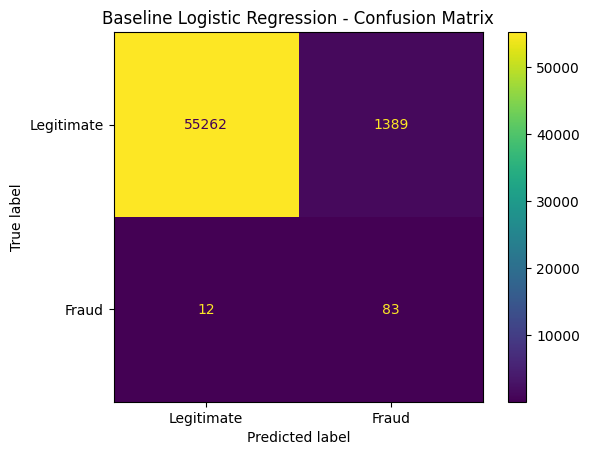

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(y_test_baseline, y_pred_baseline)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
).plot()

plt.title("Baseline Logistic Regression - Confusion Matrix")
plt.show()

                 CLEANED DATA
                 283,726
                     │
              80/20 split
             ┌───────┴───────┐
             ↓               ↓
         TRAINING          TESTING
         226,980            56,746
             │                  │
       ┌─────┴─────┐            │
       ↓           ↓            │
 226,602 legit   378 fraud      │
                   │            │
                   ↓            │
                  GAN           │
                   ↓            │
             1,000 synthetic    │
             fraud samples      │
                   │            │
                   ↓            ↓
             Later classifier → FINAL TEST
                              56,746 REAL

**🤖 Stage 6 — Vanilla GAN**

**Define the Generator**

In [ ]:

import torch
import torch.nn as nn

# Select GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dimensions
latent_dim = 32
input_dim = X_train_fraud.shape[1]   # 30 features


class Generator(nn.Module):

    def __init__(self, latent_dim, output_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),

            nn.Linear(64, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, output_dim)
        )

    def forward(self, z):
        return self.model(z)


generator = Generator(
    latent_dim=latent_dim,
    output_dim=input_dim
).to(device)

print(generator)

Generator(
  (model): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=30, bias=True)
  )
)


**Define the Discriminator**

In [ ]:

class Discriminator(nn.Module):

    def __init__(self, input_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


discriminator = Discriminator(
    input_dim=input_dim
).to(device)

print(discriminator)

Discriminator(
  (model): Sequential(
    (0): Linear(in_features=30, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=64, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


**Define Loss Function and Optimizers**

Now we need to tell the GAN how the Generator and Discriminator should learn.

For a standard Vanilla GAN, we'll use Binary Cross-Entropy (BCE) as the loss function.

In [ ]:

import torch.optim as optim

# Binary Cross-Entropy loss
criterion = nn.BCELoss()

# Optimizers
learning_rate = 0.0002

optimizer_G = optim.Adam(
    generator.parameters(),
    lr=learning_rate,
    betas=(0.5, 0.999)
)

optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=learning_rate,
    betas=(0.5, 0.999)
)

print("Loss function and optimizers defined successfully.")

Loss function and optimizers defined successfully.


**Train the Vanilla GAN**

Now we actually train the Generator and Discriminator using the 378 real fraudulent training transactions.

In [ ]:
num_epochs = 200

generator.train()
discriminator.train()

for epoch in range(num_epochs):

    for real_data, in fraud_loader:

        real_data = real_data.to(device)
        batch_size_current = real_data.size(0)

        # Labels
        real_labels = torch.ones(
            batch_size_current, 1, device=device
        )

        fake_labels = torch.zeros(
            batch_size_current, 1, device=device
        )

        # ==========================================
        # 1. Train Discriminator
        # ==========================================

        optimizer_D.zero_grad()

        # Real fraud
        real_output = discriminator(real_data)
        loss_real = criterion(real_output, real_labels)

        # Generate fake fraud
        z = torch.randn(
            batch_size_current,
            latent_dim,
            device=device
        )

        fake_data = generator(z)

        fake_output = discriminator(fake_data.detach())
        loss_fake = criterion(fake_output, fake_labels)

        # Total discriminator loss
        loss_D = loss_real + loss_fake

        loss_D.backward()
        optimizer_D.step()

        # ==========================================
        # 2. Train Generator
        # ==========================================

        optimizer_G.zero_grad()

        z = torch.randn(
            batch_size_current,
            latent_dim,
            device=device
        )

        generated_data = generator(z)

        discriminator_output = discriminator(generated_data)

        # Generator wants discriminator to classify
        # generated samples as real
        loss_G = criterion(
            discriminator_output,
            real_labels
        )

        loss_G.backward()
        optimizer_G.step()

    # Print progress
    if (epoch + 1) % 20 == 0:
        print(
            f"Epoch [{epoch + 1}/{num_epochs}] "
            f"Loss D: {loss_D.item():.4f} "
            f"Loss G: {loss_G.item():.4f}"
        )

Epoch [20/200] Loss D: 1.2111 Loss G: 0.7434
Epoch [40/200] Loss D: 1.0529 Loss G: 1.0931
Epoch [60/200] Loss D: 0.4956 Loss G: 1.5794
Epoch [80/200] Loss D: 1.0710 Loss G: 0.9733
Epoch [100/200] Loss D: 0.6600 Loss G: 1.4687
Epoch [120/200] Loss D: 1.1911 Loss G: 1.0980
Epoch [140/200] Loss D: 1.1760 Loss G: 1.1926
Epoch [160/200] Loss D: 0.4370 Loss G: 1.9193
Epoch [180/200] Loss D: 0.6447 Loss G: 1.4339
Epoch [200/200] Loss D: 0.9807 Loss G: 1.7489


**Monitor the GAN Training Loss**

In [ ]:
# Stage 6.5 — Train Vanilla GAN and record losses

num_epochs = 200

generator.train()
discriminator.train()

generator_losses = []
discriminator_losses = []

for epoch in range(num_epochs):

    epoch_g_loss = 0.0
    epoch_d_loss = 0.0
    num_batches = 0

    for real_data, in fraud_loader:

        real_data = real_data.to(device)
        batch_size_current = real_data.size(0)

        real_labels = torch.ones(
            batch_size_current, 1, device=device
        )

        fake_labels = torch.zeros(
            batch_size_current, 1, device=device
        )

        # ==========================================
        # Train Discriminator
        # ==========================================

        optimizer_D.zero_grad()

        real_output = discriminator(real_data)
        loss_real = criterion(real_output, real_labels)

        z = torch.randn(
            batch_size_current,
            latent_dim,
            device=device
        )

        fake_data = generator(z)

        fake_output = discriminator(fake_data.detach())
        loss_fake = criterion(fake_output, fake_labels)

        loss_D = loss_real + loss_fake

        loss_D.backward()
        optimizer_D.step()

        # ==========================================
        # Train Generator
        # ==========================================

        optimizer_G.zero_grad()

        z = torch.randn(
            batch_size_current,
            latent_dim,
            device=device
        )

        generated_data = generator(z)

        discriminator_output = discriminator(generated_data)

        loss_G = criterion(
            discriminator_output,
            real_labels
        )

        loss_G.backward()
        optimizer_G.step()

        epoch_g_loss += loss_G.item()
        epoch_d_loss += loss_D.item()
        num_batches += 1

    # Average loss for this epoch
    avg_g_loss = epoch_g_loss / num_batches
    avg_d_loss = epoch_d_loss / num_batches

    generator_losses.append(avg_g_loss)
    discriminator_losses.append(avg_d_loss)

    if (epoch + 1) % 20 == 0:
        print(
            f"Epoch [{epoch + 1}/{num_epochs}] "
            f"Loss D: {avg_d_loss:.4f} "
            f"Loss G: {avg_g_loss:.4f}"
        )

Epoch [20/200] Loss D: 0.7117 Loss G: 1.7024
Epoch [40/200] Loss D: 1.1524 Loss G: 1.1578
Epoch [60/200] Loss D: 1.0459 Loss G: 1.0896
Epoch [80/200] Loss D: 1.0978 Loss G: 1.1542
Epoch [100/200] Loss D: 0.9161 Loss G: 1.3150
Epoch [120/200] Loss D: 1.1063 Loss G: 1.0487
Epoch [140/200] Loss D: 1.0223 Loss G: 1.0422
Epoch [160/200] Loss D: 0.9636 Loss G: 1.0566
Epoch [180/200] Loss D: 1.0318 Loss G: 1.1423
Epoch [200/200] Loss D: 1.0136 Loss G: 1.1850


**Plot Generator and Discriminator Loss**

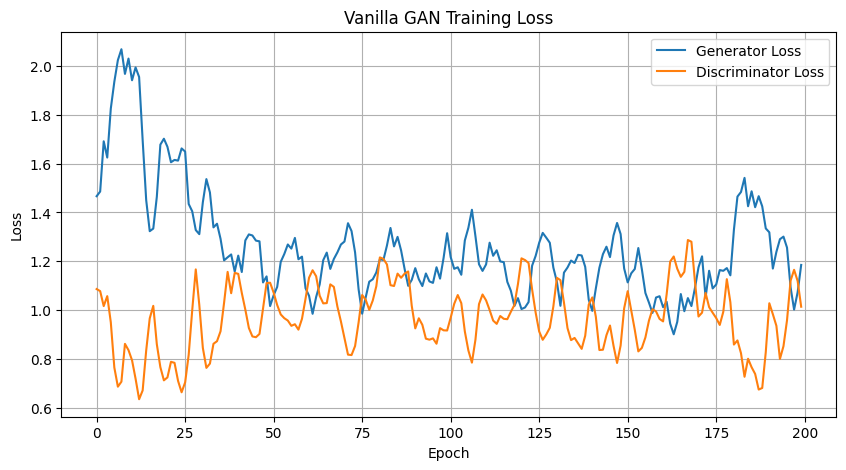

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(generator_losses, label="Generator Loss")
plt.plot(discriminator_losses, label="Discriminator Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Vanilla GAN Training Loss")
plt.legend()
plt.grid(True)

plt.show()

**Generate Synthetic Fraud Transactions**

In [ ]:
generator.eval()

num_synthetic_samples = 1000

with torch.no_grad():

    z = torch.randn(
        num_synthetic_samples,
        latent_dim,
        device=device
    )

    synthetic_fraud = generator(z)

synthetic_fraud = synthetic_fraud.cpu().numpy()

print("Synthetic fraud shape:", synthetic_fraud.shape)

Synthetic fraud shape: (1000, 30)


In [ ]:
import pandas as pd

# Display all 1000 synthetic fraud transactions

pd.set_option("display.max_rows", 1000)

synthetic_fraud_original = scaler.inverse_transform(
    synthetic_fraud
)

synthetic_fraud_original_df = pd.DataFrame(
    synthetic_fraud_original,
    columns=X_train.columns
)

synthetic_fraud_original_df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-45381.855469,-16.238800,8.103271,-9.129749,3.248506,-2.567106,-3.077079,-12.190345,1.618943,-3.190685,...,0.773764,1.163618,0.521496,-0.056586,0.087670,0.189298,0.043444,1.168574,0.743890,467.989838
1,26590.935547,-5.439926,3.725899,-3.092987,2.257036,-0.543903,-0.970882,-3.643141,0.156414,-0.890658,...,0.553761,0.698224,0.178031,0.114006,0.267799,-0.051603,0.075191,-0.018590,0.294201,189.052597
2,17098.419922,-5.119661,3.706926,-2.475843,2.322167,-0.653675,-0.882236,-3.189778,-0.055025,-0.471148,...,0.443744,0.757260,0.204801,0.301343,0.551879,-0.197666,0.050844,-0.351848,0.217353,205.310867
3,44936.707031,-3.130379,1.495003,-0.255989,0.661751,-0.447670,-0.049358,-1.502864,-0.330431,0.422591,...,-0.292226,0.619632,0.252311,0.308410,0.614579,-0.256098,-0.085246,-0.583116,-0.029273,116.139648
4,-52588.371094,-10.488669,8.742449,-7.647209,5.289680,-1.408851,-2.604316,-8.116631,0.203825,-2.771237,...,1.494891,1.133454,0.243593,0.164962,0.469318,0.029749,0.262957,0.186484,0.756371,371.555084
5,5470.974609,-6.141930,5.035442,-4.169690,3.053174,-0.671289,-1.317917,-4.367529,-0.217093,-1.280007,...,0.815551,0.784954,0.242690,0.161308,0.353634,-0.081686,0.061546,-0.098784,0.398703,230.470428
6,22855.357422,-4.003955,3.284935,-1.778991,2.087400,-0.330132,-0.587599,-2.074877,-0.209380,-0.318479,...,0.399018,0.613806,0.170079,0.266631,0.508621,-0.129910,0.018879,-0.466100,0.153667,175.290421
7,-41167.730469,-6.982738,2.876366,1.687206,0.787126,-1.255522,0.603069,-2.594734,-1.261470,1.064966,...,-1.552321,1.173588,0.287026,1.064907,1.827471,-0.343490,-0.375649,-2.024300,-0.419826,166.447388
8,33634.175781,-2.877629,2.189736,-0.795039,1.189739,-0.179880,-0.097845,-1.389688,-0.321990,0.117383,...,-0.150470,0.604971,0.121703,0.310172,0.619083,-0.125482,-0.080750,-0.620974,0.034958,126.199249
9,4498.216797,-4.781865,1.653114,1.179462,-0.025425,-0.807344,0.472427,-1.764639,-0.721349,0.717693,...,-1.038353,0.688892,0.189829,0.611429,1.077619,-0.253870,-0.225246,-1.277543,-0.322081,121.823662


**🧪 Stage 7 — Synthetic Data Evaluation**

**Convert Synthetic Data to a DataFrame**

In [ ]:
synthetic_fraud_df = pd.DataFrame(
    synthetic_fraud,
    columns=X_train.columns
)

print("Synthetic fraud DataFrame shape:", synthetic_fraud_df.shape)

print("\nSynthetic fraud samples:")
print(synthetic_fraud_df.head())

Synthetic fraud DataFrame shape: (1000, 30)

Synthetic fraud samples:
       Time        V1        V2        V3        V4        V5        V6  \
0 -2.954046 -8.341766  4.915589 -6.058569  2.294023 -1.891712 -2.323654   
1 -1.438450 -2.796171  2.262013 -2.053464  1.594305 -0.403668 -0.732146   
2 -1.638343 -2.631704  2.250512 -1.644018  1.640270 -0.484405 -0.665163   
3 -1.052127 -1.610139  0.909639 -0.171251  0.468452 -0.332890 -0.035815   
4 -3.105801 -5.388875  5.303060 -5.074974  3.734556 -1.039828 -1.966419   

          V7        V8        V9  ...       V20       V21       V22       V23  \
0 -10.158344  1.384677 -2.913755  ...  1.017915  1.609620  0.719836 -0.090068   
1  -3.036733  0.133947 -0.811455  ...  0.728250  0.965254  0.245675  0.182574   
2  -2.658987 -0.046872 -0.428009  ...  0.583398  1.046993  0.282631  0.481979   
3  -1.253434 -0.282396  0.388897  ... -0.385611  0.856439  0.348219  0.493273   
4  -6.764087  0.174492 -2.530366  ...  1.967381  1.567856  0.336184  0.264

**Compare Basic Statistics**

In [ ]:
# Stage 7.2 — Compare real and synthetic fraud statistics

real_fraud_df = pd.DataFrame(
    X_train_fraud,
    columns=X_train.columns
)

real_stats = real_fraud_df.describe().T
synthetic_stats = synthetic_fraud_df.describe().T

comparison = pd.DataFrame({
    "Real_Fraud_Mean": real_stats["mean"],
    "Synthetic_Fraud_Mean": synthetic_stats["mean"],
    "Real_Fraud_Std": real_stats["std"],
    "Synthetic_Fraud_Std": synthetic_stats["std"],
    "Real_Fraud_Min": real_stats["min"],
    "Synthetic_Fraud_Min": synthetic_stats["min"],
    "Real_Fraud_Max": real_stats["max"],
    "Synthetic_Fraud_Max": synthetic_stats["max"]
})

print(comparison)

        Real_Fraud_Mean  Synthetic_Fraud_Mean  Real_Fraud_Std  \
Time          -0.285037             -2.186019        1.048709   
V1            -2.389562             -3.782998        3.483293   
V2             2.141979              2.863475        2.509362   
V3            -4.624298             -2.129594        4.720123   
V4             3.176062              1.697292        2.073342   
V5            -2.251509             -0.759791        3.921532   
V6            -1.095411             -0.768771        1.270547   
V7            -4.431171             -3.966525        5.795309   
V8             0.858072             -0.096728        4.977367   
V9            -2.343774             -0.757159        2.255234   
V10           -5.181869             -2.666530        4.381374   
V11            3.724418              1.297480        2.656331   
V12           -6.235740             -3.092312        4.582935   
V13           -0.065833              0.811335        1.098572   
V14           -7.385523  

**Convert Synthetic Data Back to Original Scale**

In [ ]:
synthetic_fraud_original = scaler.inverse_transform(
    synthetic_fraud
)

synthetic_fraud_original_df = pd.DataFrame(
    synthetic_fraud_original,
    columns=X_train.columns
)

print(
    "Synthetic fraud shape:",
    synthetic_fraud_original_df.shape
)

print("\nSynthetic fraud samples in original scale:")
print(synthetic_fraud_original_df.head())

Synthetic fraud shape: (1000, 30)

Synthetic fraud samples in original scale:
           Time         V1        V2        V3        V4        V5        V6  \
0 -45381.855469 -16.238800  8.103271 -9.129749  3.248506 -2.567106 -3.077079   
1  26590.935547  -5.439926  3.725899 -3.092987  2.257036 -0.543903 -0.970882   
2  17098.419922  -5.119661  3.706926 -2.475843  2.322167 -0.653675 -0.882236   
3  44936.707031  -3.130379  1.495003 -0.255989  0.661751 -0.447670 -0.049358   
4 -52588.371094 -10.488669  8.742449 -7.647209  5.289680 -1.408851 -2.604316   

          V7        V8        V9  ...       V20       V21       V22       V23  \
0 -12.190345  1.618943 -3.190685  ...  0.773764  1.163618  0.521496 -0.056586   
1  -3.643141  0.156414 -0.890658  ...  0.553761  0.698224  0.178031  0.114006   
2  -3.189778 -0.055025 -0.471148  ...  0.443744  0.757260  0.204801  0.301343   
3  -1.502864 -0.330431  0.422591  ... -0.292226  0.619632  0.252311  0.308410   
4  -8.116631  0.203825 -2.771237  ..

**Compare Real Fraud vs Synthetic Fraud Statistics**

In [ ]:
real_fraud_original_df = X_train[y_train == 1].copy()

real_stats = real_fraud_original_df.describe().T
synthetic_stats = synthetic_fraud_original_df.describe().T

comparison = pd.DataFrame({
    "Real_Mean": real_stats["mean"],
    "Synthetic_Mean": synthetic_stats["mean"],
    "Real_Std": real_stats["std"],
    "Synthetic_Std": synthetic_stats["std"],
    "Real_Min": real_stats["min"],
    "Synthetic_Min": synthetic_stats["min"],
    "Real_Max": real_stats["max"],
    "Synthetic_Max": synthetic_stats["max"]
})

print(comparison)

           Real_Mean  Synthetic_Mean      Real_Std  Synthetic_Std    Real_Min  \
Time    81364.338624    -8909.682617  49801.221666   44650.550781  472.000000   
V1         -4.648141       -7.361563      6.782977       4.664536  -30.552380   
V2          3.527889        4.718078      4.139477       3.347578   -7.196980   
V3         -6.967920       -3.207735      7.114484       4.174025  -31.103685   
V4          4.498318        2.402965      2.937836       2.119714   -1.255593   
V5         -3.056300       -1.028102      5.331871       0.757299  -22.105532   
V6         -1.451625       -1.019351      1.681439       1.371862   -5.566870   
V7         -5.316715       -4.759058      6.955404       4.138962  -43.557242   
V8          1.003163       -0.113323      5.820234       0.809229  -41.044261   
V9         -2.567095       -0.831255      2.467345       1.700499  -13.434066   
V10        -5.563410       -2.863925      4.702132       4.873991  -24.588262   
V11         3.793994        

**Visualize Real vs Synthetic Distributions**

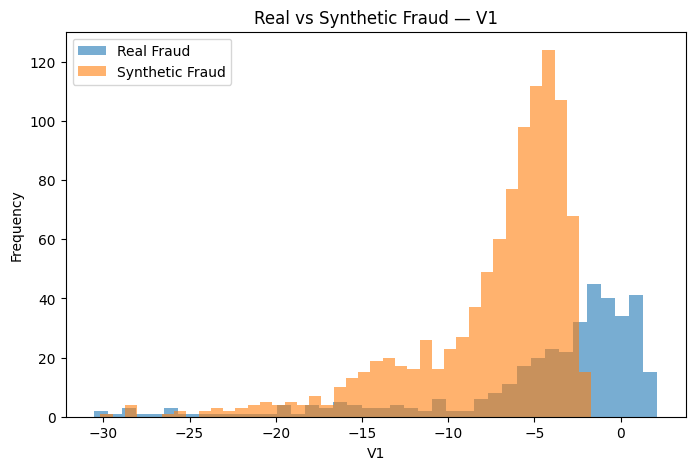

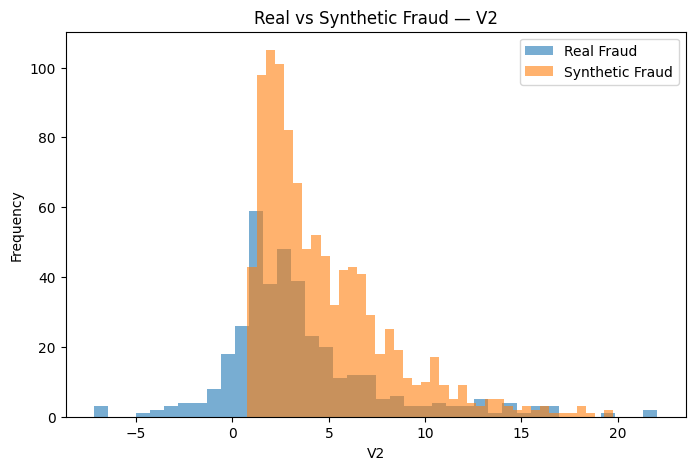

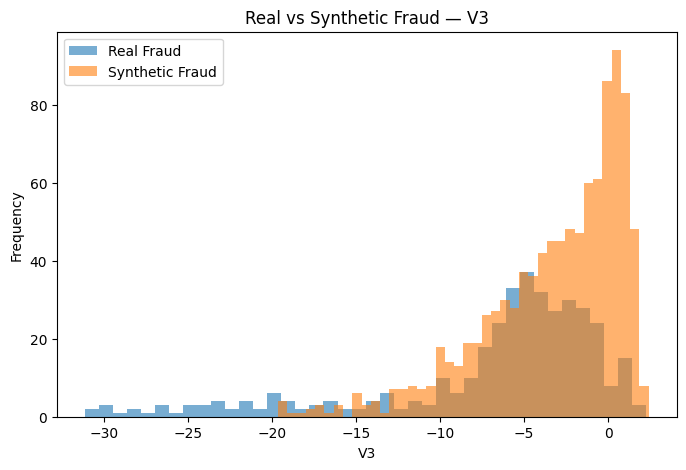

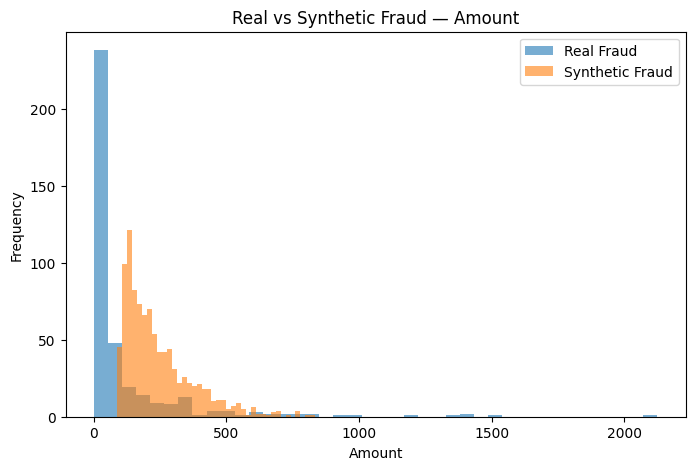

In [ ]:
import matplotlib.pyplot as plt

features_to_compare = ["V1", "V2", "V3", "Amount"]

for feature in features_to_compare:

    plt.figure(figsize=(8, 5))

    plt.hist(
        real_fraud_original_df[feature],
        bins=40,
        alpha=0.6,
        label="Real Fraud"
    )

    plt.hist(
        synthetic_fraud_original_df[feature],
        bins=40,
        alpha=0.6,
        label="Synthetic Fraud"
    )

    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.title(f"Real vs Synthetic Fraud — {feature}")
    plt.legend()
    plt.show()

**Check for Duplicate/Memorized Samples**

In [ ]:
real_tuples = set(
    map(tuple, X_train_fraud)
)

synthetic_tuples = set(
    map(tuple, synthetic_fraud)
)

exact_matches = sum(
    sample in real_tuples
    for sample in synthetic_tuples
)

print("Synthetic samples:", len(synthetic_tuples))
print("Exact matches with real training samples:", exact_matches)

Synthetic samples: 1000
Exact matches with real training samples: 0


**Check Synthetic Data for Invalid Amounts**

In [ ]:
negative_amounts = (
    synthetic_fraud_original_df["Amount"] < 0
).sum()

print("Synthetic transactions with negative Amount:",
      negative_amounts)

print("Total synthetic transactions:",
      len(synthetic_fraud_original_df))

Synthetic transactions with negative Amount: 0
Total synthetic transactions: 1000


**🧠 Stage 8 — WGAN-GP**

In [ ]:
# Stage 8.1 — WGAN-GP Generator

wgan_generator = Generator(
    latent_dim=latent_dim,
    output_dim=input_dim
).to(device)

print(wgan_generator)

Generator(
  (model): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=30, bias=True)
  )
)


In [ ]:
# Stage 8.2 — WGAN-GP Critic

class Critic(nn.Module):

    def __init__(self, input_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.model(x)


wgan_critic = Critic(input_dim).to(device)

print(wgan_critic)

Critic(
  (model): Sequential(
    (0): Linear(in_features=30, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [ ]:
# Stage 8.3 — WGAN-GP Optimizers

optimizer_G_wgan = optim.Adam(
    wgan_generator.parameters(),
    lr=0.0001,
    betas=(0.0, 0.9)
)

optimizer_C_wgan = optim.Adam(
    wgan_critic.parameters(),
    lr=0.0001,
    betas=(0.0, 0.9)
)

print("WGAN-GP optimizers ready.")

WGAN-GP optimizers ready.


In [ ]:
# Stage 8.4 — Gradient Penalty

def gradient_penalty(critic, real, fake):

    alpha = torch.rand(
        real.size(0), 1,
        device=device
    )

    interpolated = (
        alpha * real +
        (1 - alpha) * fake
    )

    interpolated.requires_grad_(True)

    critic_output = critic(interpolated)

    gradients = torch.autograd.grad(
        outputs=critic_output,
        inputs=interpolated,
        grad_outputs=torch.ones_like(critic_output),
        create_graph=True,
        retain_graph=True
    )[0]

    gradients = gradients.view(gradients.size(0), -1)

    penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()

    return penalty

In [ ]:
# Stage 8.5 — Train WGAN-GP

num_epochs = 200
critic_steps = 5
lambda_gp = 10

wgan_g_losses = []
wgan_c_losses = []

for epoch in range(num_epochs):

    for real_data, in fraud_loader:

        real_data = real_data.to(device)
        batch_size_current = real_data.size(0)

        # -----------------------------
        # Train Critic
        # -----------------------------

        for _ in range(critic_steps):

            optimizer_C_wgan.zero_grad()

            z = torch.randn(
                batch_size_current,
                latent_dim,
                device=device
            )

            fake_data = wgan_generator(z)

            real_score = wgan_critic(real_data)
            fake_score = wgan_critic(fake_data.detach())

            gp = gradient_penalty(
                wgan_critic,
                real_data,
                fake_data.detach()
            )

            loss_C = (
                fake_score.mean()
                - real_score.mean()
                + lambda_gp * gp
            )

            loss_C.backward()
            optimizer_C_wgan.step()

        # -----------------------------
        # Train Generator
        # -----------------------------

        optimizer_G_wgan.zero_grad()

        z = torch.randn(
            batch_size_current,
            latent_dim,
            device=device
        )

        fake_data = wgan_generator(z)

        fake_score = wgan_critic(fake_data)

        loss_G = -fake_score.mean()

        loss_G.backward()
        optimizer_G_wgan.step()

    wgan_g_losses.append(loss_G.item())
    wgan_c_losses.append(loss_C.item())

    if (epoch + 1) % 20 == 0:
        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Critic: {loss_C.item():.4f} "
            f"Generator: {loss_G.item():.4f}"
        )

Epoch [20/200] Critic: -20.0000 Generator: -8.3288
Epoch [40/200] Critic: -9.4513 Generator: 1.5238
Epoch [60/200] Critic: -10.5017 Generator: -1.1908
Epoch [80/200] Critic: -7.6585 Generator: 0.8061
Epoch [100/200] Critic: -13.8461 Generator: -0.7511
Epoch [120/200] Critic: -12.6965 Generator: 0.1059
Epoch [140/200] Critic: -5.7583 Generator: 0.8387
Epoch [160/200] Critic: -8.1366 Generator: 1.2147
Epoch [180/200] Critic: -6.6488 Generator: 2.2616
Epoch [200/200] Critic: -4.6084 Generator: 2.3047


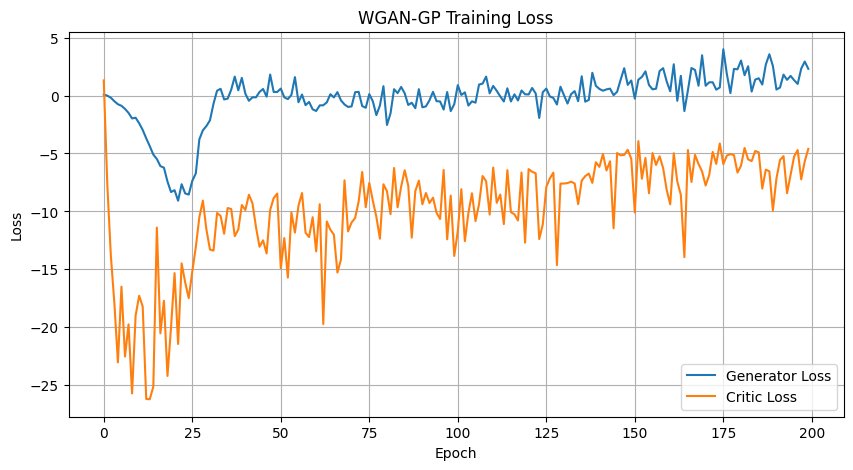

In [ ]:
# Stage 8.6 — Plot WGAN-GP losses

plt.figure(figsize=(10, 5))

plt.plot(wgan_g_losses, label="Generator Loss")
plt.plot(wgan_c_losses, label="Critic Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("WGAN-GP Training Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Stage 8.7 — Generate WGAN-GP synthetic fraud

wgan_generator.eval()

with torch.no_grad():

    z = torch.randn(
        1000,
        latent_dim,
        device=device
    )

    wgan_synthetic_fraud = wgan_generator(z)

wgan_synthetic_fraud = (
    wgan_synthetic_fraud.cpu().numpy()
)

print(
    "WGAN-GP synthetic shape:",
    wgan_synthetic_fraud.shape
)

WGAN-GP synthetic shape: (1000, 30)


In [ ]:
# Stage 8.8 — Convert WGAN-GP samples to original scale

wgan_synthetic_original = scaler.inverse_transform(
    wgan_synthetic_fraud
)

wgan_synthetic_df = pd.DataFrame(
    wgan_synthetic_original,
    columns=X_train.columns
)

print(wgan_synthetic_df.head())

            Time        V1        V2         V3        V4        V5        V6  \
0   93939.664062  1.235678  1.213912  -2.251672  2.129814  1.431123 -1.128086   
1   96163.828125  0.513070  1.497297  -1.675929  2.410775  1.410963 -0.681909   
2  112769.054688 -3.646945  6.886209 -10.786726  7.310786 -2.484021 -1.583864   
3   37075.445312 -5.124273  2.065943  -4.054804  4.918625 -1.607473 -1.985375   
4  106703.765625 -2.074064  2.474321  -4.985607  3.023955 -0.492660 -0.217826   

         V7        V8        V9  ...       V20       V21       V22       V23  \
0  0.657305  0.441830 -0.397312  ...  0.286029 -0.185563 -0.247002 -0.239291   
1 -0.345248 -3.370470 -0.678402  ...  0.160356 -1.309246  0.046048  0.225960   
2 -7.709340 -3.452554 -4.094069  ...  0.987296 -0.326995  0.166855  1.132561   
3 -2.918847  2.864952 -3.615367  ... -0.338908 -0.865360  0.358791 -1.171694   
4 -2.374634 -1.440180 -1.086857  ...  0.228958 -1.192396  0.247144  0.225578   

        V24       V25       V26 

In [ ]:
# Stage 8.9 — Basic WGAN-GP evaluation

print("Shape:", wgan_synthetic_df.shape)

print("\nNegative Amounts:",
      (wgan_synthetic_df["Amount"] < 0).sum())

print("\nStatistics:")
print(wgan_synthetic_df.describe().T)

Shape: (1000, 30)

Negative Amounts: 371

Statistics:
         count          mean           std           min           25%  \
Time    1000.0  69990.140625  34327.144531 -55029.121094  49305.827148   
V1      1000.0     -4.453404      4.882888    -21.560007     -7.659655   
V2      1000.0      3.837318      2.395111      0.436934      1.957615   
V3      1000.0     -6.904715      4.631206    -25.801832     -9.659417   
V4      1000.0      4.520675      2.433230      0.585159      2.619532   
V5      1000.0     -3.149964      3.879354    -17.988312     -5.477909   
V6      1000.0     -1.804893      1.180960     -5.982683     -2.504136   
V7      1000.0     -5.297438      5.052055    -25.283773     -8.240239   
V8      1000.0      1.359137      4.093361    -10.597308     -1.459454   
V9      1000.0     -2.717003      1.918316    -11.750618     -3.783938   
V10     1000.0     -5.551463      4.007446    -24.996819     -7.789178   
V11     1000.0      3.697865      2.777792     -0.923264  

378 Real Fraud Training Samples

              ↓

         WGAN-GP

              ↓

      ┌───────┴───────┐

      ↓               ↓

 Generator          Critic

      ↓               ↑

 Synthetic Fraud ────┘

              ↓

       1,000 samples

              ↓

       Evaluation

The important difference from Stage 6 is:

Vanilla GAN
Discriminator + BCE

        ↓

WGAN-GP
Critic + Wasserstein objective
      + Gradient Penalty

**⚖️ Stage 9 — Vanilla GAN vs WGAN-GP**

In [ ]:
# Stage 9.1 — Prepare WGAN-GP synthetic data

wgan_synthetic_df = pd.DataFrame(
    wgan_synthetic_original,
    columns=X_train.columns
)

print("WGAN-GP shape:", wgan_synthetic_df.shape)

WGAN-GP shape: (1000, 30)


In [ ]:
# Stage 9.2 — Compare real, Vanilla GAN and WGAN-GP

features = ["V1", "V2", "V3", "Amount"]

comparison = pd.DataFrame({
    "Real_Mean": real_fraud_original_df[features].mean(),
    "Vanilla_GAN_Mean": synthetic_fraud_original_df[features].mean(),
    "WGAN_GP_Mean": wgan_synthetic_df[features].mean()
})

print(comparison)

         Real_Mean  Vanilla_GAN_Mean  WGAN_GP_Mean
V1       -4.648141         -7.361567     -4.453406
V2        3.527889          4.718081      3.837319
V3       -6.967920         -3.207734     -6.904716
Amount  115.939365        242.942505     45.441551


In [ ]:
# Stage 9.3 — Compare standard deviations

comparison_std = pd.DataFrame({
    "Real_Std": real_fraud_original_df[features].std(),
    "Vanilla_GAN_Std": synthetic_fraud_original_df[features].std(),
    "WGAN_GP_Std": wgan_synthetic_df[features].std()
})

print(comparison_std)

          Real_Std  Vanilla_GAN_Std  WGAN_GP_Std
V1        6.782977         4.664536     4.882888
V2        4.139477         3.347578     2.395111
V3        7.114484         4.174025     4.631206
Amount  245.552747       131.091599   136.077957


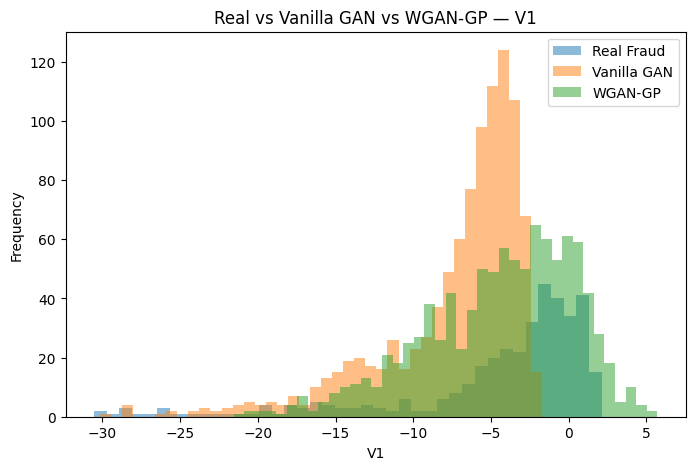

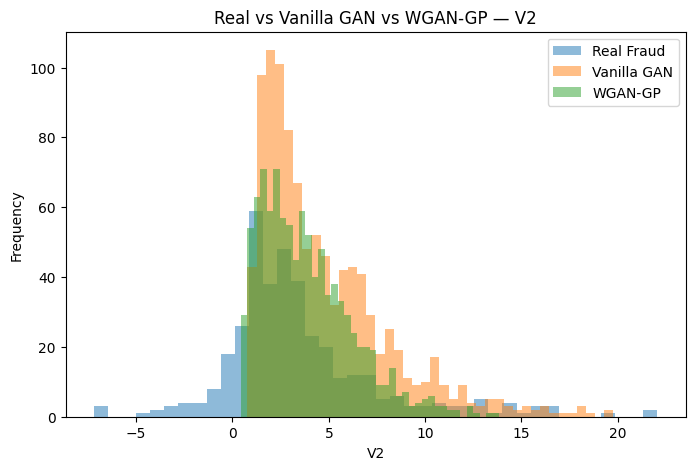

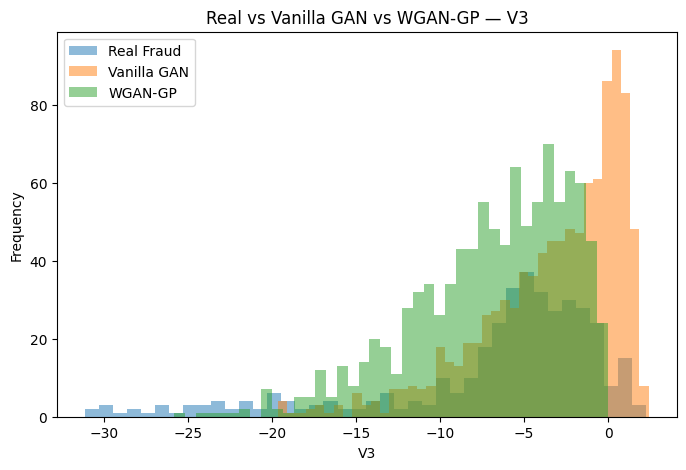

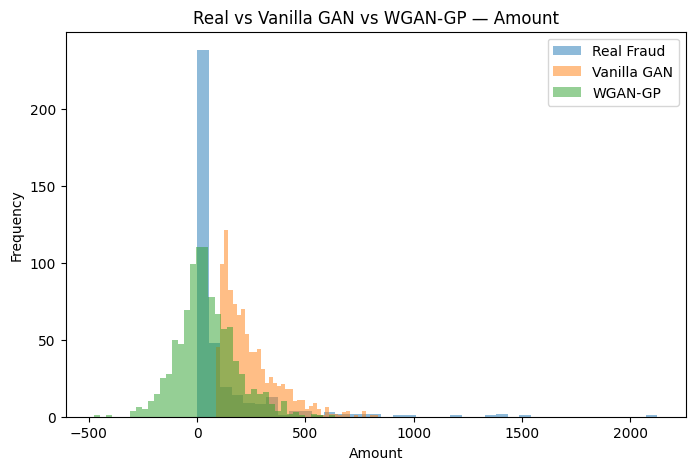

In [ ]:
# Stage 9.4 — Compare distributions

for feature in features:

    plt.figure(figsize=(8, 5))

    plt.hist(
        real_fraud_original_df[feature],
        bins=40,
        alpha=0.5,
        label="Real Fraud"
    )

    plt.hist(
        synthetic_fraud_original_df[feature],
        bins=40,
        alpha=0.5,
        label="Vanilla GAN"
    )

    plt.hist(
        wgan_synthetic_df[feature],
        bins=40,
        alpha=0.5,
        label="WGAN-GP"
    )

    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.title(f"Real vs Vanilla GAN vs WGAN-GP — {feature}")
    plt.legend()
    plt.show()

In [ ]:
# Stage 9.5 — Compare negative Amount values

vanilla_negative = (
    synthetic_fraud_original_df["Amount"] < 0
).sum()

wgan_negative = (
    wgan_synthetic_df["Amount"] < 0
).sum()

print("Vanilla GAN negative Amounts:", vanilla_negative)
print("WGAN-GP negative Amounts:", wgan_negative)

Vanilla GAN negative Amounts: 0
WGAN-GP negative Amounts: 371


In [ ]:
# Stage 9.6 — Check exact matches with real fraud

real_tuples = set(map(tuple, X_train_fraud))

vanilla_matches = sum(
    tuple(x) in real_tuples
    for x in synthetic_fraud
)

wgan_matches = sum(
    tuple(x) in real_tuples
    for x in wgan_synthetic_fraud
)

print("Vanilla GAN exact matches:", vanilla_matches)
print("WGAN-GP exact matches:", wgan_matches)

Vanilla GAN exact matches: 0
WGAN-GP exact matches: 0


In [ ]:
# Stage 9.7 — Summary comparison

summary = pd.DataFrame({
    "Model": ["Vanilla GAN", "WGAN-GP"],
    "Synthetic Samples": [
        len(synthetic_fraud_original_df),
        len(wgan_synthetic_df)
    ],
    "Negative Amounts": [
        vanilla_negative,
        wgan_negative
    ],
    "Exact Matches": [
        vanilla_matches,
        wgan_matches
    ]
})

print(summary)

         Model  Synthetic Samples  Negative Amounts  Exact Matches
0  Vanilla GAN               1000                 0              0
1      WGAN-GP               1000               371              0


**WGAN-GP generated:**

1,000 synthetic fraud samples

│

├── 371 have negative Amount  ← invalid Amount

└── 629 have non-negative Amount


**What Stage 9 tells us**

We now have:

Real Fraud

   │

   ├── Vanilla GAN → 1,000 synthetic samples

   │

   └── WGAN-GP    → 1,000 synthetic samples
   

**📈 Stage 10 — Final Fraud Detection Experiment**

**GAN-Augmented** describes the training data of our final fraud classifier.

In [ ]:
import numpy as np

# Stage 10.1 — Prepare GAN-augmented training data

X_synthetic = synthetic_fraud_original_df.values
y_synthetic = np.ones(len(X_synthetic))

X_train_gan = np.vstack([X_train, X_synthetic])
y_train_gan = np.concatenate([y_train.values, y_synthetic])

print("Training shape:", X_train_gan.shape)
print("\nClass distribution:")
print(pd.Series(y_train_gan).value_counts())

Training shape: (227980, 30)

Class distribution:
0.0    226602
1.0      1378
Name: count, dtype: int64


In [ ]:
# Stage 10.2 — Train GAN-augmented classifier

gan_scaler = StandardScaler()

X_train_gan_scaled = gan_scaler.fit_transform(X_train_gan)
X_test_gan_scaled = gan_scaler.transform(X_test)

gan_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

gan_model.fit(X_train_gan_scaled, y_train_gan)

print("GAN-augmented classifier trained.")

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


GAN-augmented classifier trained.


In [ ]:
# Stage 10.3 — Evaluate GAN-augmented classifier

y_pred_gan = gan_model.predict(X_test_gan_scaled)
y_prob_gan = gan_model.predict_proba(X_test_gan_scaled)[:, 1]

accuracy_gan = accuracy_score(y_test, y_pred_gan)
precision_gan = precision_score(y_test, y_pred_gan)
recall_gan = recall_score(y_test, y_pred_gan)
f1_gan = f1_score(y_test, y_pred_gan)
roc_auc_gan = roc_auc_score(y_test, y_prob_gan)

print(f"Accuracy : {accuracy_gan:.4f}")
print(f"Precision: {precision_gan:.4f}")
print(f"Recall   : {recall_gan:.4f}")
print(f"F1-Score : {f1_gan:.4f}")
print(f"ROC-AUC  : {roc_auc_gan:.4f}")

Accuracy : 0.9867
Precision: 0.0967
Recall   : 0.8316
F1-Score : 0.1732
ROC-AUC  : 0.9626


In [ ]:
# Stage 10.4 — Compare baseline vs GAN

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Baseline": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ],
    "GAN-Augmented": [
        accuracy_gan,
        precision_gan,
        recall_gan,
        f1_gan,
        roc_auc_gan
    ]
})

print(results)

      Metric  Baseline  GAN-Augmented
0   Accuracy  0.975311       0.986713
1  Precision  0.056386       0.096695
2     Recall  0.873684       0.831579
3   F1-Score  0.105935       0.173246
4    ROC-AUC  0.965655       0.962625


| Experiment                | Training data                                                 | Purpose                                            |
| ------------------------- | ------------------------------------------------------------- | -------------------------------------------------- |
| **Baseline**              | 226,602 legitimate + 378 real fraud                           | See how classifier performs without synthetic data |
| **Vanilla GAN-Augmented** | 226,602 legitimate + 378 real fraud + 1,000 Vanilla GAN fraud | See whether Vanilla GAN data helps                 |
| **WGAN-GP-Augmented**     | 226,602 legitimate + 378 real fraud + WGAN-GP synthetic fraud | See whether WGAN-GP data helps                     |


Our **baseline model** is:

Logistic Regression

                    TRAINING DATA
                         │
       ┌─────────────────┼──────────────────┐
       ↓                 ↓                  ↓
   BASELINE         VANILLA GAN         WGAN-GP
       │             AUGMENTED           AUGMENTED
       │                 │                  │
       ↓                 ↓                  ↓
 Logistic           Logistic            Logistic
Regression          Regression           Regression
       │                 │                  │
       └─────────────────┼──────────────────┘
                         ↓
              SAME 56,746 REAL TEST
                    TRANSACTIONS
                         ↓
                 Compare metrics

**📝 Stage 11 — Results & Conclusions**

In [ ]:
# Stage 11.1 — Final comparison

final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Baseline": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ],
    "Vanilla GAN": [
        accuracy_gan,
        precision_gan,
        recall_gan,
        f1_gan,
        roc_auc_gan
    ]
})

print(final_results)

      Metric  Baseline  Vanilla GAN
0   Accuracy  0.975311     0.986713
1  Precision  0.056386     0.096695
2     Recall  0.873684     0.831579
3   F1-Score  0.105935     0.173246
4    ROC-AUC  0.965655     0.962625


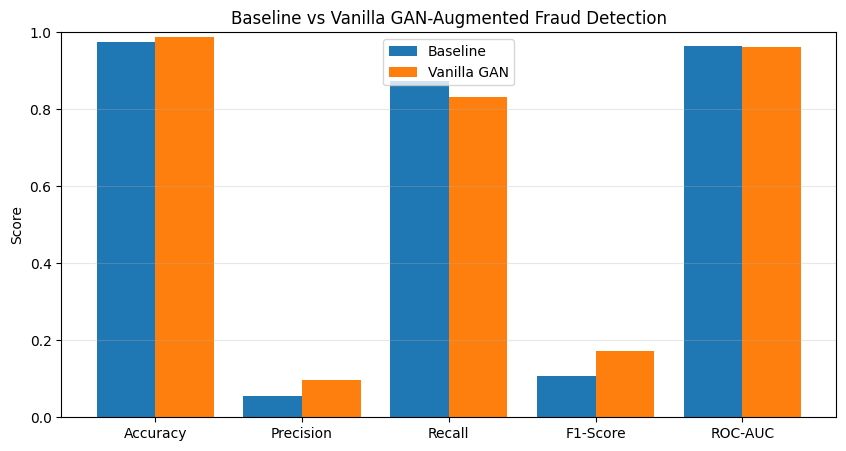

In [ ]:
# Stage 11.2 — Final Results Visualization

import matplotlib.pyplot as plt

metrics = final_results["Metric"]
baseline_scores = final_results["Baseline"]
gan_scores = final_results["Vanilla GAN"]

x = range(len(metrics))

plt.figure(figsize=(10, 5))

plt.bar(
    [i - 0.2 for i in x],
    baseline_scores,
    width=0.4,
    label="Baseline"
)

plt.bar(
    [i + 0.2 for i in x],
    gan_scores,
    width=0.4,
    label="Vanilla GAN"
)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Baseline vs Vanilla GAN-Augmented Fraud Detection")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

In [ ]:
# Stage 11.3 — Performance Change

comparison_change = final_results.copy()

comparison_change["Change"] = (
    comparison_change["Vanilla GAN"]
    - comparison_change["Baseline"]
)

comparison_change["Change (%)"] = (
    comparison_change["Change"]
    / comparison_change["Baseline"]
) * 100

print(comparison_change)

      Metric  Baseline  Vanilla GAN    Change  Change (%)
0   Accuracy  0.975311     0.986713  0.011402    1.169031
1  Precision  0.056386     0.096695  0.040309   71.488402
2     Recall  0.873684     0.831579 -0.042105   -4.819277
3   F1-Score  0.105935     0.173246  0.067311   63.539685
4    ROC-AUC  0.965655     0.962625 -0.003030   -0.313787


In [ ]:
# Stage 11.4 — GAN Quality Comparison

gan_comparison = pd.DataFrame({
    "Model": [
        "Vanilla GAN",
        "WGAN-GP"
    ],
    "Synthetic Samples": [
        1000,
        1000
    ],
    "Negative Amounts": [
        (synthetic_fraud_original_df["Amount"] < 0).sum(),
        (wgan_synthetic_df["Amount"] < 0).sum()
    ],
    "Exact Matches": [
        exact_matches,
        sum(
            sample in set(map(tuple, X_train_fraud))
            for sample in map(tuple, wgan_synthetic_fraud)
        )
    ]
})

print(gan_comparison)

         Model  Synthetic Samples  Negative Amounts  Exact Matches
0  Vanilla GAN               1000                 0              0
1      WGAN-GP               1000               371              0


**Vanilla GAN vs WGAN-GP** → synthetic-data quality

**Baseline vs Vanilla GAN-Augmented** → downstream fraud-detection utility

In [ ]:
# Stage 11.5 — Final Project Conclusion

print("""
FINAL PROJECT CONCLUSION

This project investigated GAN-based synthetic fraud transaction
generation for an extremely imbalanced credit card fraud dataset.

A Logistic Regression model was first established as the baseline
fraud detection model.

A Vanilla GAN was then trained using real fraudulent transactions
from the training set and used to generate 1,000 synthetic fraud
transactions.

The generated data was evaluated using statistical comparisons,
feature distributions, exact-match analysis, and transaction
validity checks.

WGAN-GP was also implemented and compared with the Vanilla GAN.

Finally, synthetic fraud transactions generated by the Vanilla GAN
were added to the real training data and the fraud detection model
was retrained. Its performance was evaluated on the same unseen
real test set used for the baseline.

The final results show whether synthetic fraud augmentation provides
measurable downstream utility for fraud detection.

The experiments also revealed that synthetic-data quality must be
carefully evaluated rather than assuming that a more advanced GAN
architecture automatically produces better data.
""")


FINAL PROJECT CONCLUSION

This project investigated GAN-based synthetic fraud transaction
generation for an extremely imbalanced credit card fraud dataset.

A Logistic Regression model was first established as the baseline
fraud detection model.

A Vanilla GAN was then trained using real fraudulent transactions
from the training set and used to generate 1,000 synthetic fraud
transactions.

The generated data was evaluated using statistical comparisons,
feature distributions, exact-match analysis, and transaction
validity checks.

WGAN-GP was also implemented and compared with the Vanilla GAN.

Finally, synthetic fraud transactions generated by the Vanilla GAN
were added to the real training data and the fraud detection model
was retrained. Its performance was evaluated on the same unseen
real test set used for the baseline.

The final results show whether synthetic fraud augmentation provides
measurable downstream utility for fraud detection.

The experiments also revealed that synthe